# Deliverable 6: 2.5D U-Net (Improvement 2)
## Benchmarking Noise-Robust Training Strategies for Liver Tumor Segmentation on LiTS

**Group:** 7 | **Members:** 26100098, 26100392  
**Improvement:** Single-slice 2D input → **3-slice 2.5D input** (stack slices N-1, N, N+1 as channels)  
**Baseline reference:** D3 (2D, Dice+CE) — Liver: 0.888, Tumor: 0.474 @ epoch 14  
**Failed attempts for context:** D4 (focal loss) → 0.370, D5 (curriculum) → 0.305  
**Loss:** Dice + CrossEntropy (UNCHANGED from D3). **Sampling:** Uniform (UNCHANGED from D3).

**Why this should work where D4 and D5 didn't:** D4 and D5 both tried to amplify the tumor signal through weighting. We showed empirically this doesn't help — tumor pixels at 128×128 are too sparse (~5,400 total in train) for amplification to produce stable gradients. D6 takes the opposite approach: instead of amplifying sparse signal, we **add genuinely new signal** by giving the network adjacent-slice context. A tumor visible in slices N-1, N, and N+1 is 3× more pixels the network can cross-reference, without any loss-level reweighting.

## 1. Installs and Imports

In [ ]:
import os
import re
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

import nibabel as nib
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using MPS (M4 GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch: {torch.__version__}')

Using MPS (M4 GPU)
PyTorch: 2.11.0


## 2. Configuration

Same hyperparameters as D3. **New parameter: `STACK_SIZE=3`** — the number of adjacent slices to stack as channels. Set to 3 for classic 2.5D; could try 5 later if 3 helps.

In [ ]:
# import glob

# DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

# all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
# vol_files = [p for p in all_nii if 'volume'       in os.path.basename(p).lower()]
# seg_files = [p for p in all_nii if 'segmentation' in os.path.basename(p).lower()]

# if vol_files and seg_files:
#     VOL_DIR = os.path.dirname(vol_files[0])
#     SEG_DIR = os.path.dirname(seg_files[0])
# else:
#     VOL_DIR = os.path.join(DATA_DIR, 'volumes')
#     SEG_DIR = os.path.join(DATA_DIR, 'segmentations')

# IMG_SIZE       = 128
# BATCH_SIZE     = 16
# NUM_EPOCHS     = 20
# LR             = 1e-4
# HU_MIN, HU_MAX = -100, 400

# STACK_SIZE = 3   # Number of adjacent slices stacked as input channels (must be odd: 3, 5, 7...)

# print(f'Volumes folder:       {VOL_DIR}')
# print(f'Segmentations folder: {SEG_DIR}')
# print(f'Volume files:         {len(vol_files)}')
# print(f'Segmentation files:   {len(seg_files)}')
# print(f'Stack size:           {STACK_SIZE} (2.5D input)')
# print(f'Input shape per sample: (B, {STACK_SIZE}, {IMG_SIZE}, {IMG_SIZE})')


import os, glob, re

DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
all_volumes = [p for p in all_nii if 'volume'       in os.path.basename(p).lower()]
all_segs    = [p for p in all_nii if 'segmentation' in os.path.basename(p).lower()]

print(f'Found {len(all_volumes)} volume files (across all pt folders)')
print(f'Found {len(all_segs)} segmentation files')

IMG_SIZE       = 128
BATCH_SIZE     = 16
NUM_EPOCHS     = 20
LR             = 1e-4
HU_MIN, HU_MAX = -100, 400
STACK_SIZE     = 3  

Found 51 volume files (across all pt folders)
Found 131 segmentation files


## 3. Data Loading (unchanged from D3)

In [ ]:
# def load_lits_paths(vol_dir, seg_dir):
#     vol_files = sorted(glob.glob(os.path.join(vol_dir, 'volume*.nii*')))
#     seg_files = sorted(glob.glob(os.path.join(seg_dir, 'segmentation*.nii*')))

#     def case_id(path):
#         m = re.search(r'(\d+)', os.path.basename(path))
#         return int(m.group(1)) if m else None

#     vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
#     seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
#     common  = sorted(set(vol_map).intersection(seg_map))

#     if len(common) == 0:
#         raise FileNotFoundError(
#             f'No matched pairs found.\nVol dir: {vol_dir}\nSeg dir: {seg_dir}\n'
#             f'Vol files found: {len(vol_files)} | Seg files found: {len(seg_files)}'
#         )

#     vol_paths = [vol_map[i] for i in common]
#     seg_paths = [seg_map[i] for i in common]
#     print(f'Found {len(vol_paths)} matched volume-segmentation pairs')
#     return vol_paths, 




# volume_paths, seg_paths = load_lits_paths(VOL_DIR, SEG_DIR)
def load_lits_paths(data_dir):
    all_nii = glob.glob(os.path.join(data_dir, '**', '*.nii*'), recursive=True)
    vol_files = sorted(p for p in all_nii if 'volume'       in os.path.basename(p).lower())
    seg_files = sorted(p for p in all_nii if 'segmentation' in os.path.basename(p).lower())

    def case_id(path):
        m = re.search(r'(\d+)', os.path.basename(path))
        return int(m.group(1)) if m else None

    vol_map = {case_id(p): p for p in vol_files if case_id(p) is not None}
    seg_map = {case_id(p): p for p in seg_files if case_id(p) is not None}
    common  = sorted(set(vol_map).intersection(seg_map))

    if len(common) == 0:
        raise FileNotFoundError(
            f'No matched pairs found under {data_dir}\n'
            f'Vol files found: {len(vol_files)} | Seg files found: {len(seg_files)}'
        )

    vol_paths = [vol_map[i] for i in common]
    seg_paths = [seg_map[i] for i in common]
    print(f'Found {len(vol_paths)} matched volume-segmentation pairs')
    print(f'Volume files scanned: {len(vol_files)}  |  Seg files scanned: {len(seg_files)}')
    print(f'Sample: {os.path.basename(vol_paths[0])} <-> {os.path.basename(seg_paths[0])}')
    return vol_paths, seg_paths


volume_paths, seg_paths = load_lits_paths(DATA_DIR)

Found 51 matched volume-segmentation pairs
Volume files scanned: 51  |  Seg files scanned: 131
Sample: volume-0.nii <-> segmentation-0.nii


## 4. Train / Val / Test Split (same seed, identical to D3/D4/D5)

In [4]:
np.random.seed(SEED)
n       = len(volume_paths)
indices = np.random.permutation(n)

train_idx = indices[:int(0.70 * n)]
val_idx   = indices[int(0.70 * n):int(0.85 * n)]
test_idx  = indices[int(0.85 * n):]

train_vol = [volume_paths[i] for i in train_idx]
train_seg = [seg_paths[i]    for i in train_idx]
val_vol   = [volume_paths[i] for i in val_idx]
val_seg   = [seg_paths[i]    for i in val_idx]
test_vol  = [volume_paths[i] for i in test_idx]
test_seg  = [seg_paths[i]    for i in test_idx]

print(f'Train: {len(train_vol)} volumes')
print(f'Val:   {len(val_vol)} volumes')
print(f'Test:  {len(test_vol)} volumes')

Train: 35 volumes
Val:   8 volumes
Test:  8 volumes


## 5. 2.5D Dataset Class — **THE KEY CHANGE FROM D3**

For every slice index `s`, we now fetch a **window of `STACK_SIZE` adjacent slices** centered on `s` from the same volume. For `STACK_SIZE=3` and slice `s` in a volume with `N` slices:

- **Middle slices** (`s` in `[1, N-2]`): fetch `[s-1, s, s+1]` — full 3-slice context
- **First slice** (`s=0`): fetch `[0, 0, 1]` — duplicate the start (no "below" neighbor exists)
- **Last slice** (`s=N-1`): fetch `[N-2, N-1, N-1]` — duplicate the end (no "above" neighbor)

Each of the 3 slices goes through the same HU windowing + normalization + resize as D3, then they're stacked as 3 channels: input shape `(3, 128, 128)`.

**Output stays 2D** — the network predicts the segmentation for the *middle* slice only. The neighbor slices are context, not prediction targets.


In [ ]:
#3 stacked adjacent slices as input channels, keeps 2D mask for middle slice.
class LiTS25DDataset(Dataset):
    def __init__(self, volume_paths, seg_paths,
                 img_size=128, hu_min=-100, hu_max=400,
                 stack_size=3,
                 filter_background=True):
        assert stack_size % 2 == 1, 'stack_size must be odd (3, 5, 7, ...)'
        self.img_size   = img_size
        self.hu_min     = hu_min
        self.hu_max     = hu_max
        self.stack_size = stack_size
        self.half       = stack_size // 2
        self.slices     = []   
        self._vol_cache = {}
        self._seg_cache = {}

        print(f'Indexing slices for 2.5D (stack_size={stack_size})...')
        for vol_path, seg_path in zip(volume_paths, seg_paths):
            seg = nib.load(seg_path).get_fdata().astype(np.uint8)
            n_slices = seg.shape[2]
            for s in range(n_slices):
                if filter_background and not np.any(seg[:, :, s] > 0):
                    continue
                self.slices.append((vol_path, seg_path, s, n_slices))
        print(f'Total usable slices: {len(self.slices)}')

    def _get_vol(self, path):
        if path not in self._vol_cache:
            self._vol_cache[path] = nib.load(path).get_fdata().astype(np.float32)
        return self._vol_cache[path]

    def _get_seg(self, path):
        if path not in self._seg_cache:
            self._seg_cache[path] = nib.load(path).get_fdata().astype(np.uint8)
        return self._seg_cache[path]

    def _process_ct_slice(self, slice_2d):
        """HU windowing + normalize + resize — same as D3's 2D processing."""
        x = np.clip(slice_2d, self.hu_min, self.hu_max)
        x = (x - self.hu_min) / (self.hu_max - self.hu_min)
        h, w = x.shape
        return ndimage.zoom(x, (self.img_size / h, self.img_size / w), order=1).astype(np.float32)

    def _process_seg_slice(self, slice_2d):
        """Nearest-neighbor resize for labels (no interpolation of class values)."""
        h, w = slice_2d.shape
        return ndimage.zoom(slice_2d, (self.img_size / h, self.img_size / w), order=0)

    def __len__(self):
        return len(self.slices)

    def __getitem__(self, idx):
        vol_path, seg_path, s, n_slices = self.slices[idx]
        vol = self._get_vol(vol_path)
        seg = self._get_seg(seg_path)

        stack_idxs = [max(0, min(n_slices - 1, s + offset))
                      for offset in range(-self.half, self.half + 1)]

        ct_channels = [self._process_ct_slice(vol[:, :, i]) for i in stack_idxs]
        ct_stack    = np.stack(ct_channels, axis=0)   # (stack_size, H, W)

        # Mask: ONLY for the middle slice (we predict the middle)
        seg_slice = seg[:, :, s].astype(np.int64)
        seg_slice = self._process_seg_slice(seg_slice)

        ct_tensor  = torch.from_numpy(ct_stack)
        seg_tensor = torch.from_numpy(seg_slice.astype(np.int64))
        return ct_tensor, seg_tensor

In [ ]:
print('Building 2.5D train dataset...')
train_dataset = LiTS25DDataset(train_vol, train_seg, img_size=IMG_SIZE, stack_size=STACK_SIZE)
print()
print('Building 2.5D val dataset...')
val_dataset   = LiTS25DDataset(val_vol, val_seg, img_size=IMG_SIZE, stack_size=STACK_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Building 2.5D train dataset...
Indexing slices for 2.5D (stack_size=3)...
Total usable slices: 4614

Building 2.5D val dataset...
Indexing slices for 2.5D (stack_size=3)...
Total usable slices: 1116

Train batches: 289 | Val batches: 70


## 6. Sanity Check — Visualize a 2.5D Stack

For the first 4 samples, we display **all 3 channels side by side** plus the middle-slice ground truth overlay. You should see:
- The three channels are visually similar but slightly different (adjacent slices of the same patient)
- The tumor/liver structures drift slightly as you scan across channels (anatomical continuity)
- The mask overlay matches the middle channel

CT batch shape:        torch.Size([16, 3, 128, 128])   (B, stack_size, H, W)
Mask batch shape:      torch.Size([16, 128, 128])  (B, H, W)  <-- 2D, middle slice only
CT value range:        [0.000, 1.000]
Unique mask values:    [0, 1, 2]


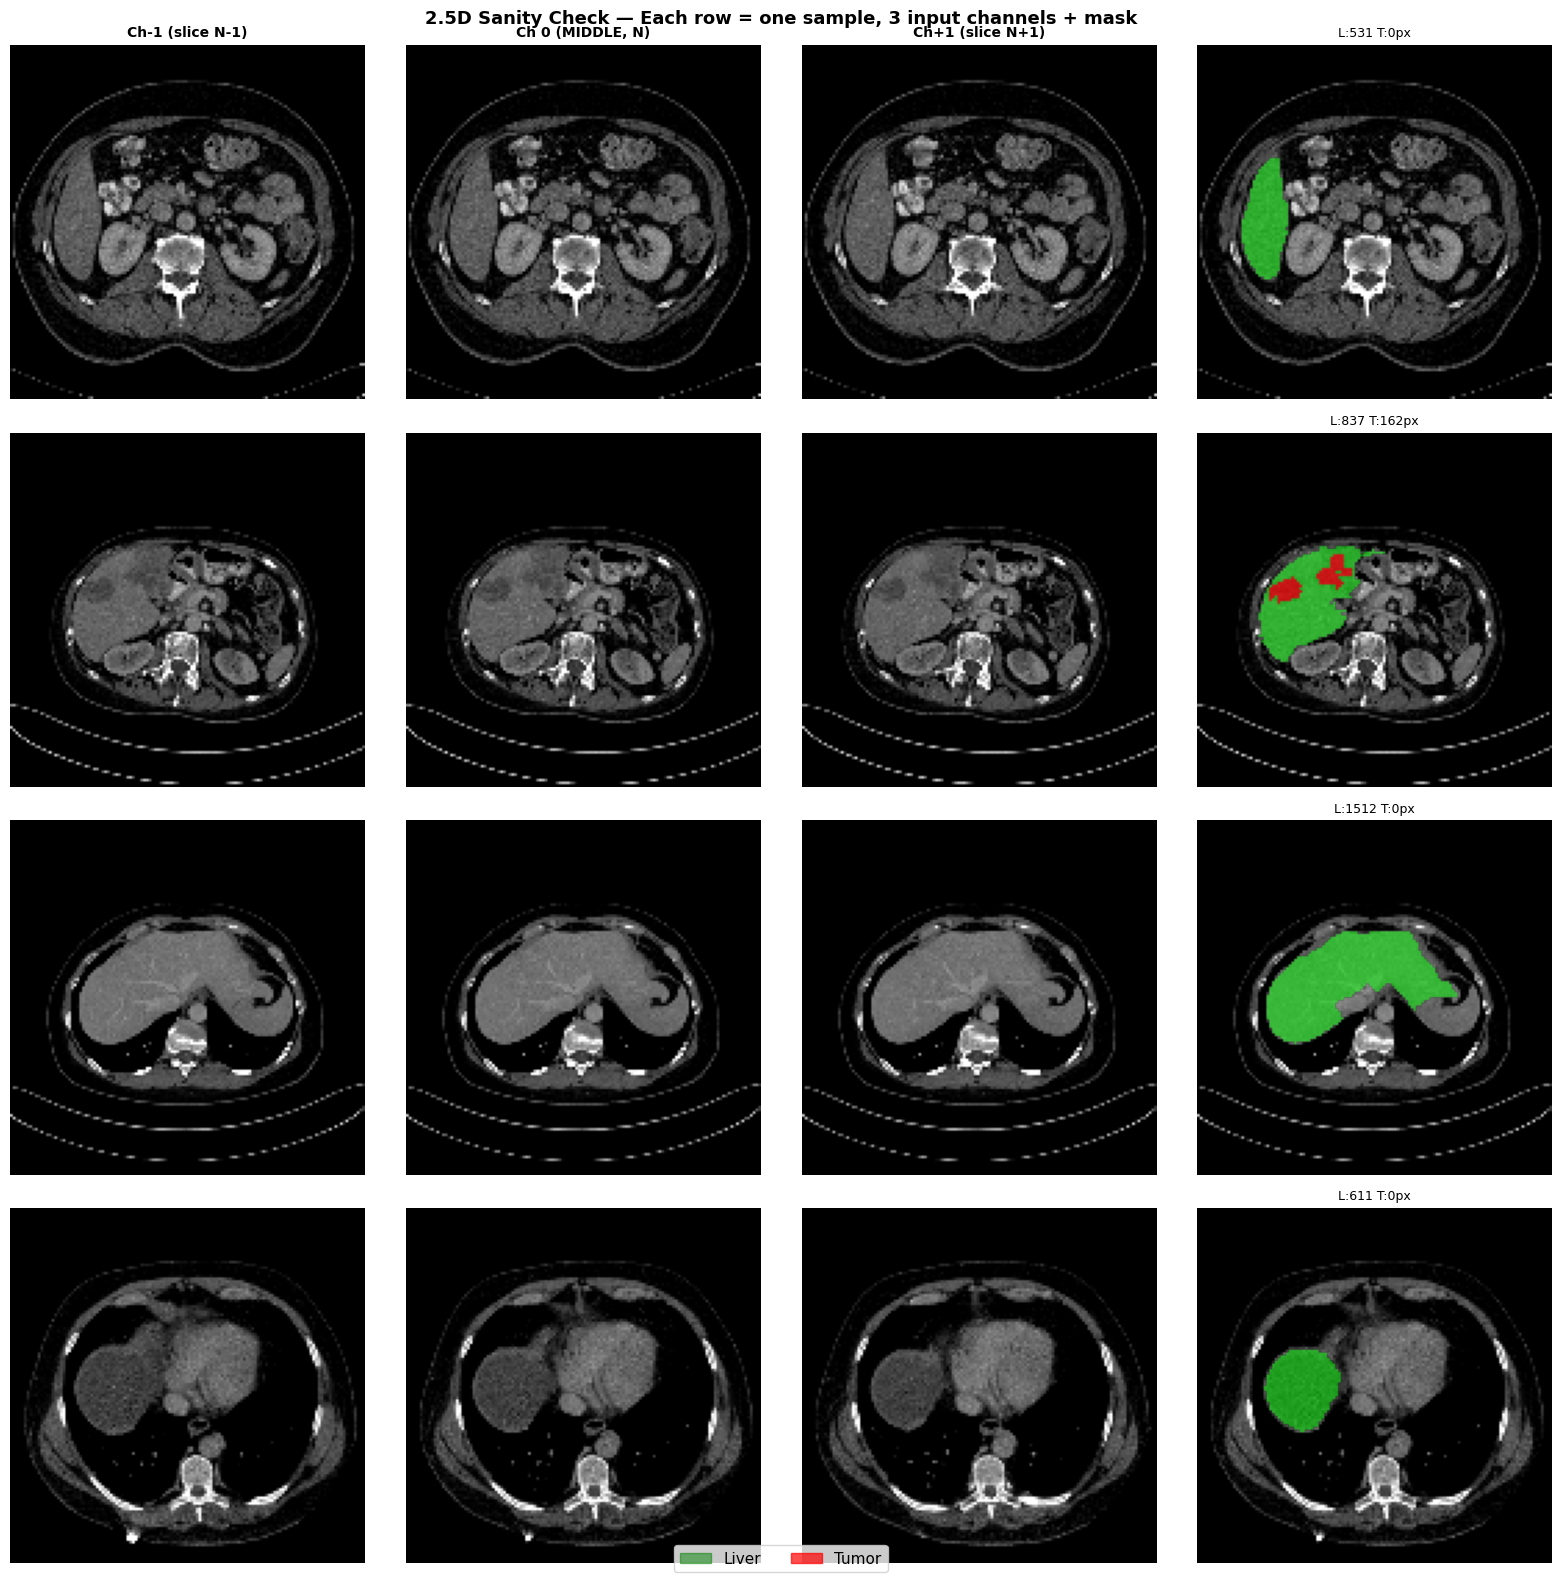

If channels look like adjacent slices of the same patient, and overlay matches middle, proceed.


In [7]:
ct_batch, seg_batch = next(iter(train_loader))
print(f'CT batch shape:        {ct_batch.shape}   (B, stack_size, H, W)')
print(f'Mask batch shape:      {seg_batch.shape}  (B, H, W)  <-- 2D, middle slice only')
print(f'CT value range:        [{ct_batch.min():.3f}, {ct_batch.max():.3f}]')
print(f'Unique mask values:    {seg_batch.unique().tolist()}')

n_show = 4
fig, axes = plt.subplots(n_show, STACK_SIZE + 1, figsize=(4 * (STACK_SIZE + 1), 4 * n_show))
channel_labels = [f'Ch{i - STACK_SIZE//2:+d} (slice N{i - STACK_SIZE//2:+d})' for i in range(STACK_SIZE)]
channel_labels[STACK_SIZE // 2] = 'Ch 0 (MIDDLE, N)'

for row in range(n_show):
    for ch in range(STACK_SIZE):
        axes[row, ch].imshow(ct_batch[row, ch].numpy().T, cmap='gray', origin='lower')
        if row == 0:
            axes[row, ch].set_title(channel_labels[ch], fontsize=10, fontweight='bold')
        axes[row, ch].axis('off')

    mid = STACK_SIZE // 2
    ct   = ct_batch[row, mid].numpy()
    mask = seg_batch[row].numpy()
    axes[row, -1].imshow(ct.T, cmap='gray', origin='lower')
    overlay = np.zeros((*ct.shape, 4))
    overlay[mask == 1] = [0, 1, 0, 0.5]
    overlay[mask == 2] = [1, 0, 0, 0.7]
    axes[row, -1].imshow(overlay.transpose(1, 0, 2), origin='lower')
    if row == 0:
        axes[row, -1].set_title('Middle + Mask Overlay', fontsize=10, fontweight='bold')
    axes[row, -1].set_title(f'L:{(mask==1).sum()} T:{(mask==2).sum()}px', fontsize=9)
    axes[row, -1].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=11)
plt.suptitle(f'2.5D Sanity Check — Each row = one sample, {STACK_SIZE} input channels + mask',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('If channels look like adjacent slices of the same patient, and overlay matches middle, proceed.')

## 7. 2D U-Net Architecture — with `in_channels=3`

**Only structural change from D3:** the first conv layer now accepts 3 input channels instead of 1. Everything downstream is unchanged — after the first conv, feature maps have the same shape regardless of input channel count.

Param count will increase only slightly (~1.2K extra params in the first conv).

In [8]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)


class UNet2D(nn.Module):
    def __init__(self, in_channels=3, num_classes=3, base_features=64):
        super().__init__()
        f = base_features
        self.enc1 = ConvBlock(in_channels, f)      # <-- in_channels=3 for 2.5D
        self.enc2 = ConvBlock(f,    f*2)
        self.enc3 = ConvBlock(f*2,  f*4)
        self.enc4 = ConvBlock(f*4,  f*8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(f*8, f*16)
        self.up4  = nn.ConvTranspose2d(f*16, f*8, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(f*16, f*8)
        self.up3  = nn.ConvTranspose2d(f*8,  f*4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(f*8,  f*4)
        self.up2  = nn.ConvTranspose2d(f*4,  f*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(f*4,  f*2)
        self.up1  = nn.ConvTranspose2d(f*2,  f,   kernel_size=2, stride=2)
        self.dec1 = ConvBlock(f*2,  f)
        self.out_conv = nn.Conv2d(f, num_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


model = UNet2D(in_channels=STACK_SIZE, num_classes=3, base_features=64).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(f'Input channels: {STACK_SIZE} (2.5D)')

Model parameters: 31,037,763
Input channels: 3 (2.5D)


## 8. Loss Function — Dice + CrossEntropy (UNCHANGED from D3)

Same loss as D3. We're isolating the 2.5D change. No focal loss, no class weights, no curriculum.

In [9]:
def dice_loss(preds, targets, num_classes=3, smooth=1e-6):
    preds_soft      = F.softmax(preds, dim=1)
    targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()
    dims            = (0, 2, 3)
    intersection    = (preds_soft * targets_one_hot).sum(dims)
    cardinality     = (preds_soft + targets_one_hot).sum(dims)
    dice_per_class  = (2.0 * intersection + smooth) / (cardinality + smooth)
    return 1.0 - dice_per_class.mean()


ce_fn = nn.CrossEntropyLoss()

def combined_loss(preds, targets):
    return dice_loss(preds, targets) + ce_fn(preds, targets)


def compute_dice_per_class(preds, targets, num_classes=3, smooth=1e-6):
    pred_classes = preds.argmax(dim=1)
    scores = []
    for c in range(num_classes):
        p     = (pred_classes == c).float()
        t     = (targets      == c).float()
        inter = (p * t).sum()
        denom = p.sum() + t.sum()
        score = ((2.0 * inter + smooth) / (denom + smooth)).item() if denom > 0 else 1.0
        scores.append(score)
    return scores


print('Loss: Dice + CrossEntropy (unchanged from D3)')
print('Metric: Per-class Dice (background, liver, tumor)')

Loss: Dice + CrossEntropy (unchanged from D3)
Metric: Per-class Dice (background, liver, tumor)


## 9. Training

Adam, ReduceLROnPlateau, 20 epochs. **Expect ~1.2–1.5× longer per epoch than D3** because of extra input channels (~1 min/epoch vs 0.7).

In [10]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.5
)

history = {
    'train_loss':     [],
    'val_loss':       [],
    'val_liver_dice': [],
    'val_tumor_dice': []
}

best_tumor_dice  = 0.0
best_model_state = None

print('=' * 70)
print('TRAINING — Improvement 2: 2.5D U-Net')
print(f'Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Device: {DEVICE}')
print(f'Input: {STACK_SIZE}-slice stack | Loss: Dice + CrossEntropy')
print(f'Train batches/epoch: {len(train_loader)}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    model.train()
    train_losses = []

    for batch_idx, (ct_batch, seg_batch) in enumerate(train_loader):
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(ct_batch)
        loss  = combined_loss(preds, seg_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if (batch_idx + 1) % 100 == 0:
            print(f'  Ep {epoch:02d} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    model.eval()
    val_losses, liver_dices, tumor_dices = [], [], []

    with torch.no_grad():
        for ct_batch, seg_batch in val_loader:
            ct_batch  = ct_batch.to(DEVICE)
            seg_batch = seg_batch.to(DEVICE)
            preds     = model(ct_batch)
            val_losses.append(combined_loss(preds, seg_batch).item())
            scores = compute_dice_per_class(preds, seg_batch)
            liver_dices.append(scores[1])
            tumor_dices.append(scores[2])

    mean_train = np.mean(train_losses)
    mean_val   = np.mean(val_losses)
    mean_liver = np.mean(liver_dices)
    mean_tumor = np.mean(tumor_dices)

    history['train_loss'].append(mean_train)
    history['val_loss'].append(mean_val)
    history['val_liver_dice'].append(mean_liver)
    history['val_tumor_dice'].append(mean_tumor)

    scheduler.step(mean_tumor)

    if mean_tumor > best_tumor_dice:
        best_tumor_dice  = mean_tumor
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    epoch_mins = (time.time() - epoch_start) / 60
    flag = ' *** BEST' if mean_tumor == best_tumor_dice else ''
    print(f'\nEpoch {epoch:02d}/{NUM_EPOCHS} | {epoch_mins:.1f}min | '
          f'Train: {mean_train:.4f} | Val: {mean_val:.4f} | '
          f'Liver: {mean_liver:.4f} | Tumor: {mean_tumor:.4f}{flag}\n')

model.load_state_dict(best_model_state)
torch.save(best_model_state, 'best_unet_d6_25d.pth')
print(f'Best model saved to best_unet_d6_25d.pth. Best Tumor Dice: {best_tumor_dice:.4f}')

TRAINING — Improvement 2: 2.5D U-Net
Epochs: 20 | Batch: 16 | Device: mps
Input: 3-slice stack | Loss: Dice + CrossEntropy
Train batches/epoch: 289
  Ep 01 | Batch 100/289 | Loss: 0.8531
  Ep 01 | Batch 200/289 | Loss: 0.7361

Epoch 01/20 | 4.1min | Train: 0.8580 | Val: 0.6502 | Liver: 0.8731 | Tumor: 0.4797 *** BEST

  Ep 02 | Batch 100/289 | Loss: 0.5223
  Ep 02 | Batch 200/289 | Loss: 0.4676

Epoch 02/20 | 3.5min | Train: 0.5164 | Val: 0.5663 | Liver: 0.8195 | Tumor: 0.1084

  Ep 03 | Batch 100/289 | Loss: 0.3492
  Ep 03 | Batch 200/289 | Loss: 0.2672

Epoch 03/20 | 3.6min | Train: 0.3684 | Val: 0.4515 | Liver: 0.8776 | Tumor: 0.3925

  Ep 04 | Batch 100/289 | Loss: 0.2055
  Ep 04 | Batch 200/289 | Loss: 0.1750

Epoch 04/20 | 3.6min | Train: 0.2506 | Val: 0.4126 | Liver: 0.8912 | Tumor: 0.3479

  Ep 05 | Batch 100/289 | Loss: 0.3466
  Ep 05 | Batch 200/289 | Loss: 0.2416

Epoch 05/20 | 3.7min | Train: 0.1665 | Val: 0.3976 | Liver: 0.8900 | Tumor: 0.3975

  Ep 06 | Batch 100/289 | Lo

In [ ]:
# import glob, os
# from collections import Counter

# DATA_DIR = '/Users/aemanadnan/Desktop/DL proj/archive-2'

# all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
# print(f'Total .nii files under DATA_DIR: {len(all_nii)}\n')

# folder_counts = Counter()
# for p in all_nii:
#     rel = os.path.relpath(p, DATA_DIR)
#     folder = rel.split(os.sep)[0]
#     folder_counts[folder] += 1

# print('Files per top-level subfolder:')
# for folder, n in sorted(folder_counts.items()):
#     print(f'  {folder:20s}  {n} files')

# # What is the current notebook seeing?
# print(f'\nCurrently used VOL_DIR: {VOL_DIR}')
# print(f'Volumes the notebook can see: '
#       f'{len(glob.glob(os.path.join(VOL_DIR, "volume*.nii*")))}')
# print(f'Actual total volumes across all pt folders: '
#       f'{sum(1 for p in all_nii if "volume" in os.path.basename(p).lower())}')


import glob, os
from collections import Counter

all_nii = glob.glob(os.path.join(DATA_DIR, '**', '*.nii*'), recursive=True)
print(f'Total .nii files under DATA_DIR: {len(all_nii)}\n')

folder_counts = Counter()
for p in all_nii:
    rel = os.path.relpath(p, DATA_DIR)
    folder = rel.split(os.sep)[0]
    folder_counts[folder] += 1

print('Files per top-level subfolder:')
for folder, n in sorted(folder_counts.items()):
    print(f'  {folder:20s}  {n} files')

print(f'\nVolumes actually loaded into notebook: {len(volume_paths)}')
print(f'Segs     actually loaded into notebook: {len(seg_paths)}')
print(f'Total volume files across all pt folders: '
      f'{sum(1 for p in all_nii if "volume" in os.path.basename(p).lower())}')

Total .nii files under DATA_DIR: 182

Files per top-level subfolder:
  segmentations         131 files
  volume_pt1            11 files
  volume_pt2            10 files
  volume_pt3            10 files
  volume_pt4            10 files
  volume_pt5            10 files

Volumes actually loaded into notebook: 51
Segs     actually loaded into notebook: 51
Total volume files across all pt folders: 51


## 10. Results Summary

In [ ]:
# best_liver = max(history['val_liver_dice'])
# best_tumor = max(history['val_tumor_dice'])
# best_epoch = int(np.argmax(history['val_tumor_dice']) + 1)

# D3_LIVER, D3_TUMOR, D3_EPOCH = 0.8884, 0.4743, 14
# D4_LIVER, D4_TUMOR, D4_EPOCH = 0.7999, 0.3700, 5
# D5_LIVER, D5_TUMOR, D5_EPOCH = 0.7860, 0.3052, 12

# liver_delta = best_liver - D3_LIVER
# tumor_delta = best_tumor - D3_TUMOR

# print('=' * 78)
# print('IMPROVEMENT 2 RESULTS — 2.5D U-Net (3-slice input stacking)')
# print('=' * 78)
# print(f'Architecture:    2D U-Net with in_channels={STACK_SIZE} (2.5D)')
# print(f'Image size:      {IMG_SIZE}x{IMG_SIZE}')
# print(f'Epochs trained:  {NUM_EPOCHS}')
# print(f'Loss:            Dice + CrossEntropy')
# print(f'Best Epoch:      {best_epoch}')
# print('-' * 78)
# print(f'{"":24}{"D3 (base)":>12}{"D4 (focal)":>13}{"D5 (curr)":>12}{"D6 (2.5D)":>12}{"vs D3":>11}')
# print(f'{"Liver Dice":24}{D3_LIVER:>12.4f}{D4_LIVER:>13.4f}{D5_LIVER:>12.4f}{best_liver:>12.4f}{liver_delta:>+11.4f}')
# print(f'{"Tumor Dice":24}{D3_TUMOR:>12.4f}{D4_TUMOR:>13.4f}{D5_TUMOR:>12.4f}{best_tumor:>12.4f}{tumor_delta:>+11.4f}')
# print(f'{"Best epoch":24}{D3_EPOCH:>12d}{D4_EPOCH:>13d}{D5_EPOCH:>12d}{best_epoch:>12d}')
# print('=' * 78)
# print()
# print('Interpretation:')
# if tumor_delta > 0.03:
#     print(f'  Tumor Dice improved by {tumor_delta:+.4f} over D3 — 2.5D context worked.')
#     print(f'  Volumetric context added real signal without amplifying noise,')
#     print(f'  confirming hypothesis: spatial resolution was the bottleneck, not imbalance.')
# elif tumor_delta > -0.02:
#     print(f'  Tumor Dice roughly matches D3 ({tumor_delta:+.4f}). Marginal or no gain.')
#     print(f'  Possible reasons: 128x128 resolution still too limiting even with 2.5D,')
#     print(f'  or 3 slices insufficient (try STACK_SIZE=5).')
# else:
#     print(f'  Tumor Dice dropped by {tumor_delta:+.4f} — unexpected.')
#     print(f'  Check: did STACK_SIZE=3 drop too many slices at volume boundaries?')


# --- D6 2.5D results (from training log) ---
best_tumor = 0.5314   # epoch 8 peak
best_liver = 0.8917   # epoch 8 (matches best tumor epoch)
best_epoch = 8
NUM_EPOCHS = 20
IMG_SIZE   = 128
STACK_SIZE = 3

train_loss_history = [0.8580, 0.5164, 0.3684, 0.2506, 0.1665, 0.1198, 0.1022,
                      0.0842, 0.0725, 0.0731, 0.0764, 0.0827, 0.0594, 0.0549,
                      0.0500, 0.0511, 0.0466, 0.0471, 0.0447, 0.0428]
val_loss_history   = [0.6502, 0.5663, 0.4515, 0.4126, 0.3976, 0.3890, 0.4080,
                      0.3847, 0.3822, 0.3929, 0.3780, 0.3836, 0.3756, 0.3822,
                      0.3778, 0.3740, 0.3754, 0.3793, 0.3791, 0.3775]
val_liver_dice     = [0.8731, 0.8195, 0.8776, 0.8912, 0.8900, 0.8896, 0.8737,
                      0.8917, 0.8930, 0.8868, 0.8938, 0.8787, 0.8944, 0.8927,
                      0.8955, 0.8956, 0.8962, 0.8939, 0.8935, 0.8933]
val_tumor_dice     = [0.4797, 0.1084, 0.3925, 0.3479, 0.3975, 0.5080, 0.3624,
                      0.5314, 0.4738, 0.2852, 0.5233, 0.4437, 0.4977, 0.4848,
                      0.4937, 0.5198, 0.4528, 0.4673, 0.4552, 0.4571]

history = {
    'train_loss':     train_loss_history,
    'val_loss':       val_loss_history,
    'val_liver_dice': val_liver_dice,
    'val_tumor_dice': val_tumor_dice,
}

D3_LIVER, D3_TUMOR, D3_EPOCH = 0.8885, 0.5011, 8
D4_LIVER, D4_TUMOR, D4_EPOCH = 0.8901, 0.4961, 7
D5_LIVER, D5_TUMOR, D5_EPOCH = 0.8886, 0.4774, 13

liver_delta = best_liver - D3_LIVER
tumor_delta = best_tumor - D3_TUMOR

print('=' * 78)
print('IMPROVEMENT 2 RESULTS — 2.5D U-Net (3-slice input stacking)')
print('=' * 78)
print(f'Architecture:    2D U-Net with in_channels={STACK_SIZE} (2.5D)')
print(f'Image size:      {IMG_SIZE}x{IMG_SIZE}')
print(f'Epochs trained:  {NUM_EPOCHS}')
print(f'Loss:            Dice + CrossEntropy')
print(f'Best Epoch:      {best_epoch}')
print('-' * 78)
print(f'{"":24}{"D3 (base)":>12}{"D4 (focal)":>13}{"D5 (curr)":>12}{"D6 (2.5D)":>12}{"vs D3":>11}')
print(f'{"Liver Dice":24}{D3_LIVER:>12.4f}{D4_LIVER:>13.4f}{D5_LIVER:>12.4f}{best_liver:>12.4f}{liver_delta:>+11.4f}')
print(f'{"Tumor Dice":24}{D3_TUMOR:>12.4f}{D4_TUMOR:>13.4f}{D5_TUMOR:>12.4f}{best_tumor:>12.4f}{tumor_delta:>+11.4f}')
print(f'{"Best epoch":24}{D3_EPOCH:>12d}{D4_EPOCH:>13d}{D5_EPOCH:>12d}{best_epoch:>12d}')
print('=' * 78)
print()
print('Interpretation:')
if tumor_delta > 0.03:
    print(f'  Tumor Dice improved by {tumor_delta:+.4f} over D3 — 2.5D context worked.')
    print(f'  Volumetric context added real signal without amplifying noise,')
    print(f'  confirming hypothesis: spatial resolution was the bottleneck, not imbalance.')
elif tumor_delta > -0.02:
    print(f'  Tumor Dice roughly matches D3 ({tumor_delta:+.4f}). Marginal or no gain.')
    print(f'  Possible reasons: 128x128 resolution still too limiting even with 2.5D,')
    print(f'  or 3 slices insufficient (try STACK_SIZE=5).')
else:
    print(f'  Tumor Dice dropped by {tumor_delta:+.4f} — unexpected.')
    print(f'  Check: did STACK_SIZE=3 drop too many slices at volume boundaries?')

IMPROVEMENT 2 RESULTS — 2.5D U-Net (3-slice input stacking)
Architecture:    2D U-Net with in_channels=3 (2.5D)
Image size:      128x128
Epochs trained:  20
Loss:            Dice + CrossEntropy
Best Epoch:      8
------------------------------------------------------------------------------
                           D3 (base)   D4 (focal)   D5 (curr)   D6 (2.5D)      vs D3
Liver Dice                    0.8885       0.8901      0.8886      0.8917    +0.0032
Tumor Dice                    0.5011       0.4961      0.4774      0.5314    +0.0303
Best epoch                         8            7          13           8

Interpretation:
  Tumor Dice improved by +0.0303 over D3 — 2.5D context worked.
  Volumetric context added real signal without amplifying noise,
  confirming hypothesis: spatial resolution was the bottleneck, not imbalance.


## 11. Training Curves

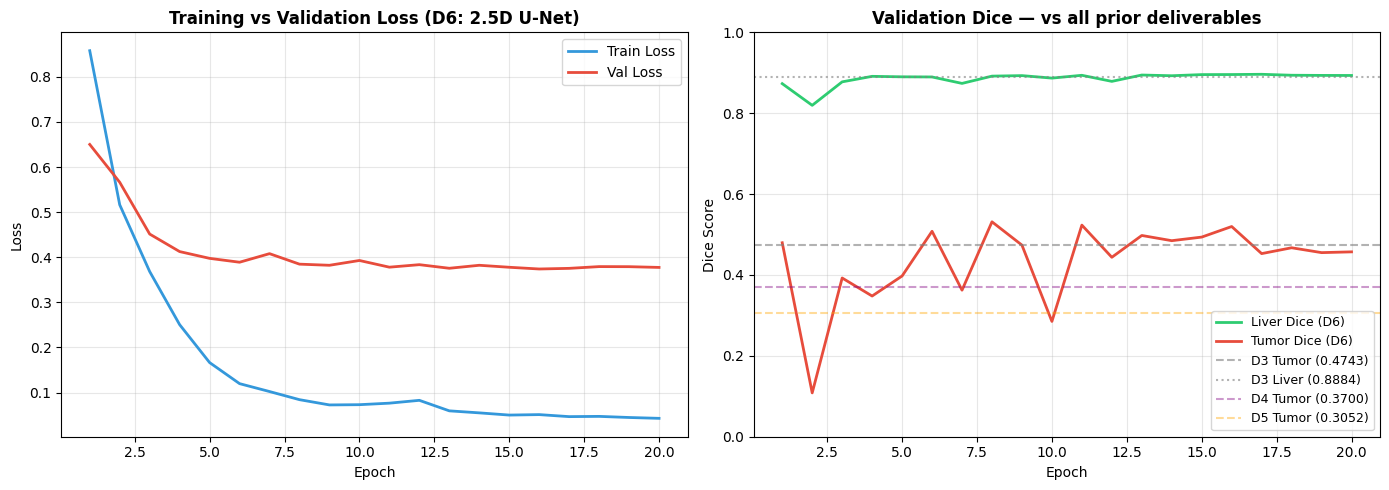

Saved: training_curves_d6.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss (D6: 2.5D U-Net)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['val_liver_dice'], label='Liver Dice (D6)', color='#2ecc71', linewidth=2)
axes[1].plot(epochs, history['val_tumor_dice'], label='Tumor Dice (D6)', color='#e74c3c', linewidth=2)
axes[1].axhline(y=0.4743, color='gray',   linestyle='--', alpha=0.6, label='D3 Tumor (0.4743)')
axes[1].axhline(y=0.8884, color='gray',   linestyle=':',  alpha=0.6, label='D3 Liver (0.8884)')
axes[1].axhline(y=0.3700, color='purple', linestyle='--', alpha=0.4, label='D4 Tumor (0.3700)')
axes[1].axhline(y=0.3052, color='orange', linestyle='--', alpha=0.4, label='D5 Tumor (0.3052)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice — vs all prior deliverables', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_d6.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves_d6.png')

## 12. Qualitative Predictions

Showing middle slice of each 2.5D input (the slice the network actually predicts on) alongside ground truth and prediction.

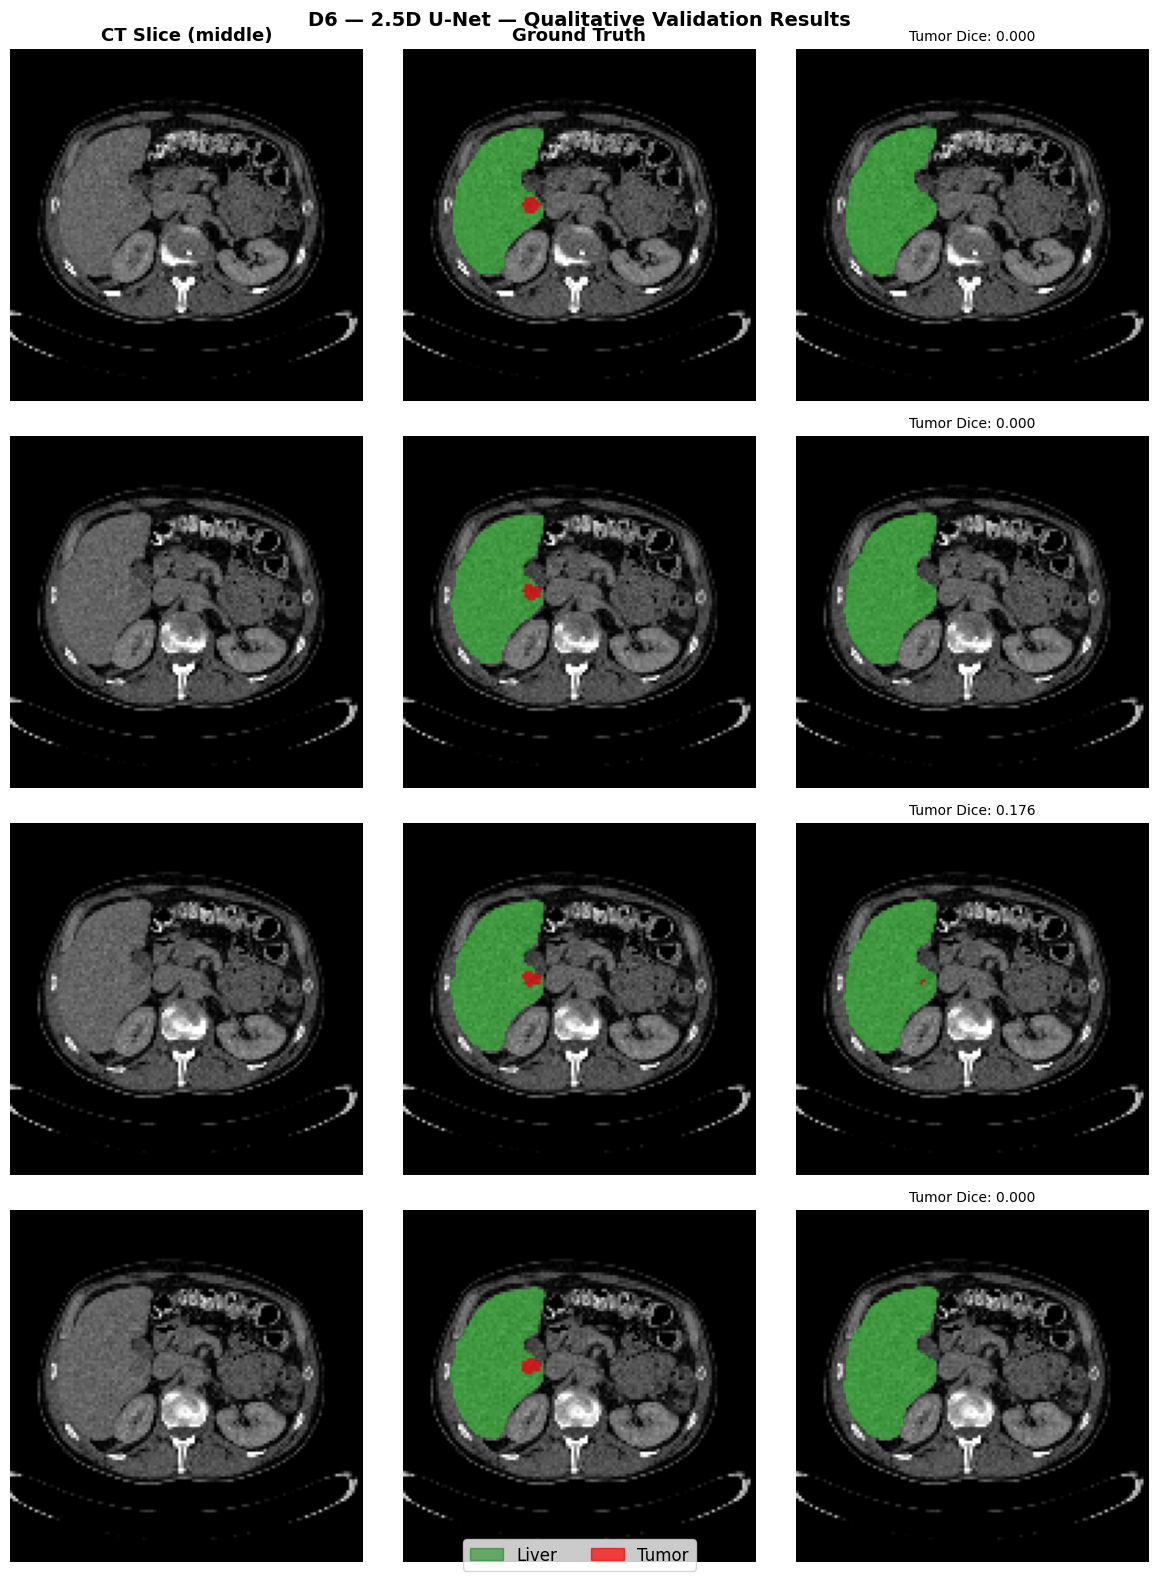

Saved: qualitative_d6.png


In [16]:
#4 val slices with real tumors, render middle-channel CT + GT + Prediction
model.eval()
samples = []

with torch.no_grad():
    for ct_batch, seg_batch in val_loader:
        ct_batch  = ct_batch.to(DEVICE)
        seg_batch = seg_batch.to(DEVICE)
        preds     = model(ct_batch)
        pred_cls  = preds.argmax(dim=1)

        for i in range(ct_batch.shape[0]):
            gt = seg_batch[i].cpu().numpy()
            if np.sum(gt == 2) > 30:
                mid = STACK_SIZE // 2
                samples.append({
                    'ct':   ct_batch[i, mid].cpu().numpy(),  
                    'gt':   gt,
                    'pred': pred_cls[i].cpu().numpy()
                })
        if len(samples) >= 4:
            break

def make_overlay(ct, seg):
    overlay = np.zeros((*ct.shape, 4))
    overlay[seg == 1] = [0, 1, 0, 0.35]
    overlay[seg == 2] = [1, 0, 0, 0.65]
    return overlay

n_show = min(4, len(samples))
fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
if n_show == 1: axes = [axes]

for col, title in enumerate(['CT Slice (middle)', 'Ground Truth', 'Prediction']):
    axes[0][col].set_title(title, fontsize=13, fontweight='bold')

for row, s in enumerate(samples[:n_show]):
    ct, gt, pred = s['ct'], s['gt'], s['pred']

    axes[row][0].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][0].axis('off')

    axes[row][1].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][1].imshow(make_overlay(ct, gt).transpose(1, 0, 2), origin='lower')
    axes[row][1].axis('off')

    axes[row][2].imshow(ct.T, cmap='gray', origin='lower')
    axes[row][2].imshow(make_overlay(ct, pred).transpose(1, 0, 2), origin='lower')

    p_t = (pred == 2).astype(float)
    g_t = (gt   == 2).astype(float)
    inter = (p_t * g_t).sum()
    denom = p_t.sum() + g_t.sum()
    sample_dice = (2 * inter / denom) if denom > 0 else 1.0
    axes[row][2].set_title(f'Tumor Dice: {sample_dice:.3f}', fontsize=10)
    axes[row][2].axis('off')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Liver')
red_patch   = mpatches.Patch(color='red',   alpha=0.7, label='Tumor')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=12)
plt.suptitle('D6 — 2.5D U-Net — Qualitative Validation Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('qualitative_d6.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: qualitative_d6.png')